In [1]:
!pip install scikeras

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout,Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam,SGD,RMSprop
from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)
from scikeras.wrappers import KerasClassifier
from sklearn.model_selection import RandomizedSearchCV
import sklearn
import scikeras
import tensorflow as tf
import time

In [3]:
plt.rcParams.update({
    'font.family': 'Liberation Serif',
    'font.size': 15,
    'font.weight': 'bold',
    'axes.labelweight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelsize': 15,
    'axes.titlesize': 15,
    'xtick.labelsize': 13,
    'ytick.labelsize': 13,
    'legend.fontsize': 13
})

In [4]:
(X_train,y_train),(X_test,y_test) = fashion_mnist.load_data()
print("Training Images :",X_train.shape)
print("Training Labels :",y_train.shape)
print("Testing Images :",X_test.shape)
print("Testing Labels :",y_test.shape)

Training Images : (60000, 28, 28)
Training Labels : (60000,)
Testing Images : (10000, 28, 28)
Testing Labels : (10000,)


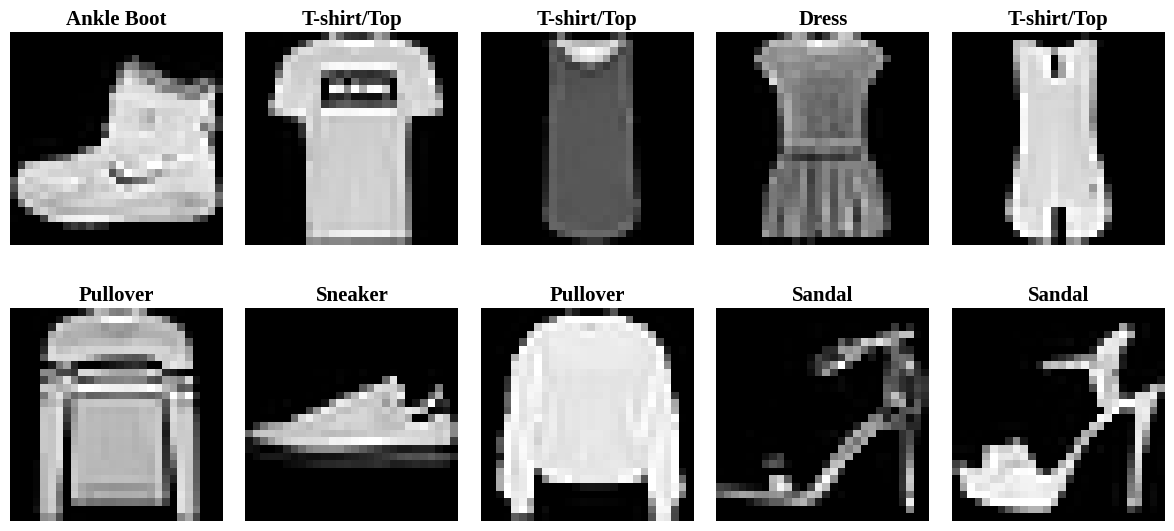

In [5]:
class_names = ["T-shirt/Top","Trouser","Pullover","Dress","Coat","Sandal","Shirt","Sneaker","Bag","Ankle Boot"]
plt.figure(figsize=(12, 6))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.savefig("Sample_Images.eps", format="eps", bbox_inches="tight")
plt.show()

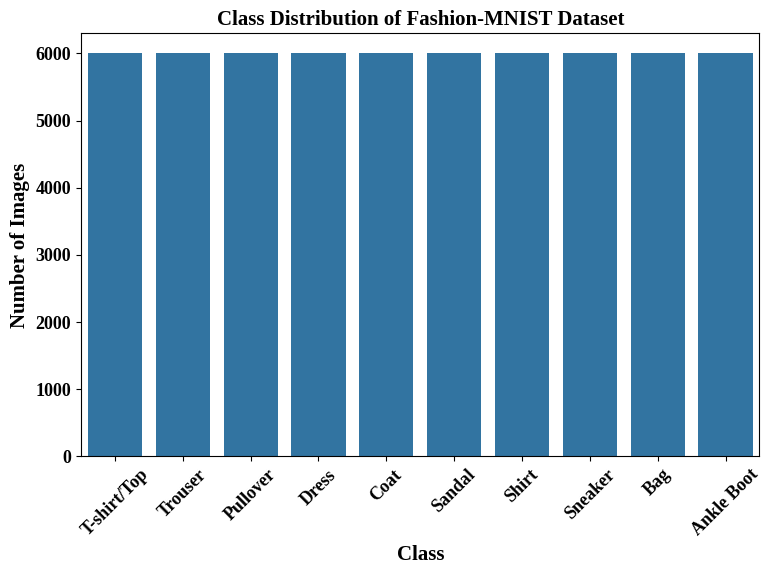

In [6]:
plt.figure(figsize=(8,6))
sns.countplot(x=y_train)
plt.title("Class Distribution of Fashion-MNIST Dataset")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.xticks(ticks=range(10),labels=class_names,rotation=45)
plt.tight_layout()
plt.savefig("Class_Distribution.eps", format="eps", bbox_inches="tight")
plt.show()

In [7]:
print("Before Preprocessing")
print("Training Images Shape :",X_train.shape)
print("Testing Images Shape :",X_test.shape)
X_train = X_train.reshape(X_train.shape[0],784)
X_test = X_test.reshape(X_test.shape[0],784)
print("After Flattening")
print("Training Images Shape :",X_train.shape)
print("Testing Images Shape :",X_test.shape)

Before Preprocessing
Training Images Shape : (60000, 28, 28)
Testing Images Shape : (10000, 28, 28)
After Flattening
Training Images Shape : (60000, 784)
Testing Images Shape : (10000, 784)


In [8]:
X_train = X_train.astype("float32")/255
X_test = X_test.astype("float32")/255

In [9]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)
print("Training Labels Shape :",y_train_cat.shape)
print("Testing Labels Shape :",y_test_cat.shape)
print("Before One-Hot Encoding :",y_train[0])
print("After One-Hot Encoding :",y_train_cat[0])

Training Labels Shape : (60000, 10)
Testing Labels Shape : (10000, 10)
Before One-Hot Encoding : 9
After One-Hot Encoding : [0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]


In [10]:
model = Sequential()
model.add(Input(shape=(784,)))
model.add(Dense(128, activation="relu"))
model.add(Dense(64, activation="relu"))
model.add(Dense(10, activation="softmax"))
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(optimizer="adam",loss="categorical_crossentropy",metrics=["accuracy"])

In [12]:
start_time = time.time()
history = model.fit(X_train,y_train_cat,epochs=20,batch_size=32,validation_split=0.2)
end_time = time.time()
baseline_training_time = end_time - start_time
print(f"Baseline Training Time: {baseline_training_time:.2f} seconds")

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.7657 - loss: 0.6656 - val_accuracy: 0.8606 - val_loss: 0.3917
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.8604 - loss: 0.3829 - val_accuracy: 0.8614 - val_loss: 0.3859
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8764 - loss: 0.3359 - val_accuracy: 0.8740 - val_loss: 0.3466
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8850 - loss: 0.3049 - val_accuracy: 0.8789 - val_loss: 0.3425
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8907 - loss: 0.2923 - val_accuracy: 0.8763 - val_loss: 0.3416
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8960 - loss: 0.2777 - val_accuracy: 0.8804 - val_loss: 0.3294
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9000 - loss: 0.2644 - val_accuracy: 0.8873 - val_loss: 0.3153
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9052 - loss: 0.2540 -

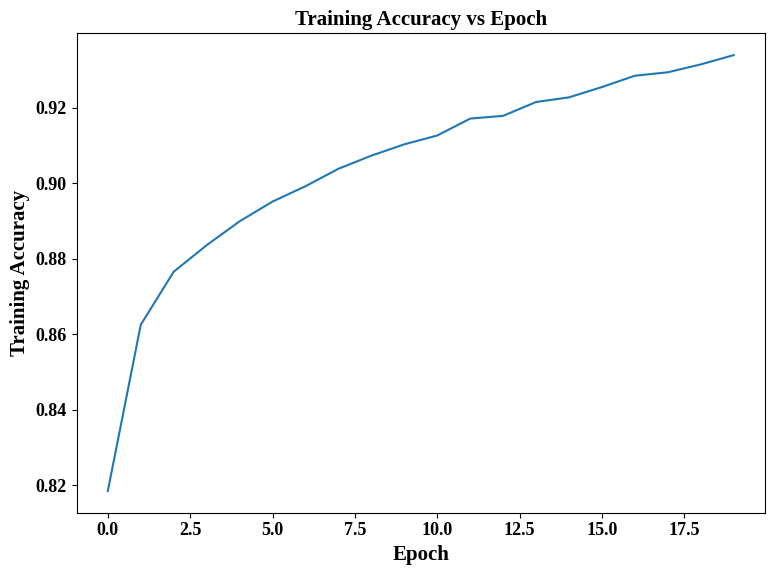

In [13]:
plt.figure(figsize=(8,6))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.title("Training Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Accuracy")
plt.tight_layout()
plt.savefig("Training_Accuracy_vs_Epoch.eps",format="eps",bbox_inches="tight")
plt.show()

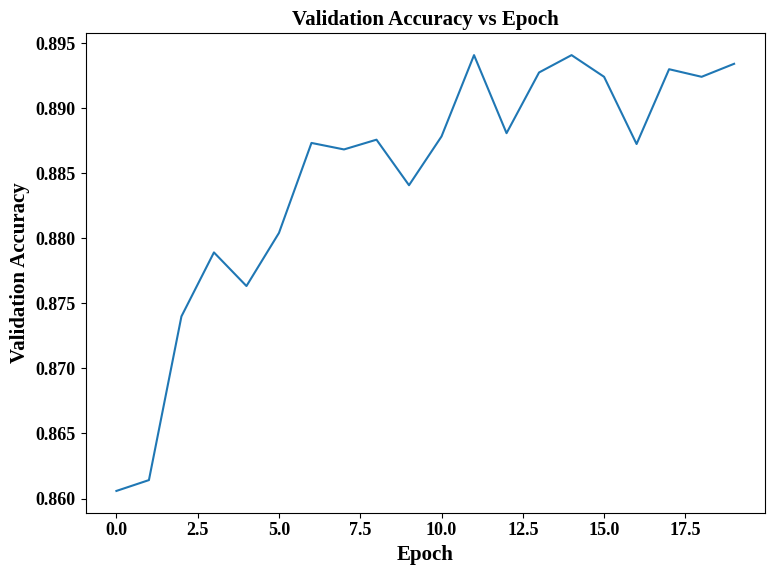

In [14]:
plt.figure(figsize=(8,6))
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.title("Validation Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.tight_layout()
plt.savefig("Validation_Accuracy_vs_Epoch.eps",format="eps",bbox_inches="tight")
plt.show()

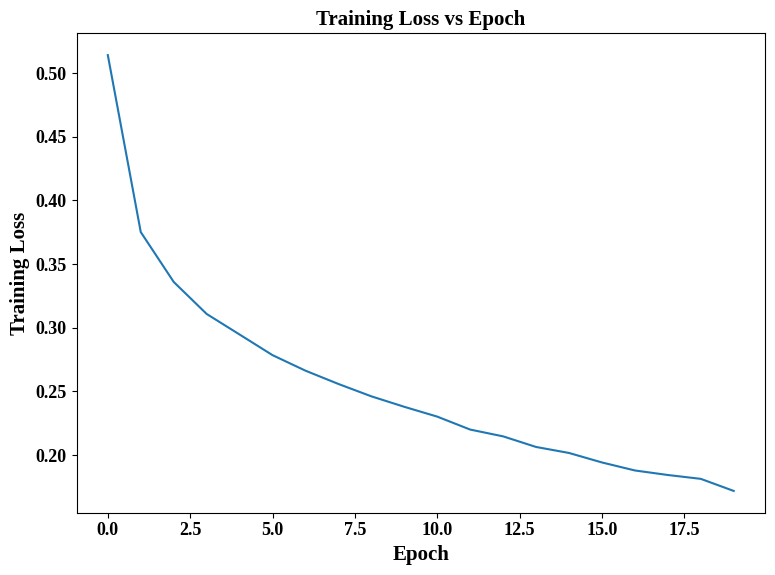

In [15]:
plt.figure(figsize=(8,6))
plt.plot(history.history["loss"],label="Training Loss")
plt.title("Training Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.tight_layout()
plt.savefig("Training_Loss_vs_Epoch.eps",format="eps",bbox_inches="tight")
plt.show()

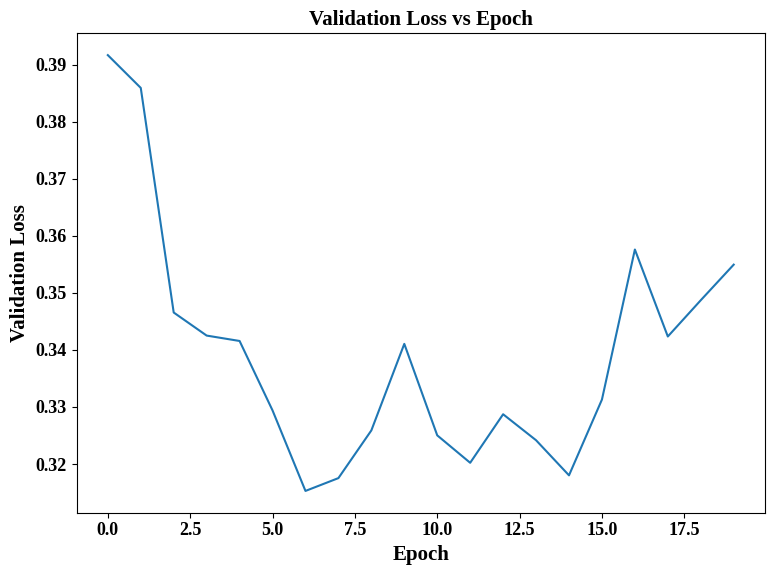

In [16]:
plt.figure(figsize=(8,6))
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.title("Validation Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Validation Loss")
plt.tight_layout()
plt.savefig("Validation_Loss_vs_Epoch.eps",format="eps",bbox_inches="tight")
plt.show()

In [17]:
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true,y_pred,average="weighted")
recall = recall_score(y_true,y_pred,average="weighted")
f1 = f1_score(y_true,y_pred,average="weighted")
print("Accuracy :",accuracy)
print("Precision :",precision)
print("Recall :",recall)
print("F1 Score :",f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Accuracy : 0.8853
Precision : 0.885448707444351
Recall : 0.8853
F1 Score : 0.8852124454574128


In [18]:
print(classification_report(y_true,y_pred,target_names=class_names))

              precision    recall  f1-score   support

 T-shirt/Top       0.83      0.83      0.83      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.79      0.81      0.80      1000
       Dress       0.88      0.91      0.89      1000
        Coat       0.81      0.80      0.80      1000
      Sandal       0.97      0.95      0.96      1000
       Shirt       0.71      0.69      0.70      1000
     Sneaker       0.93      0.97      0.95      1000
         Bag       0.97      0.97      0.97      1000
  Ankle Boot       0.97      0.94      0.95      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



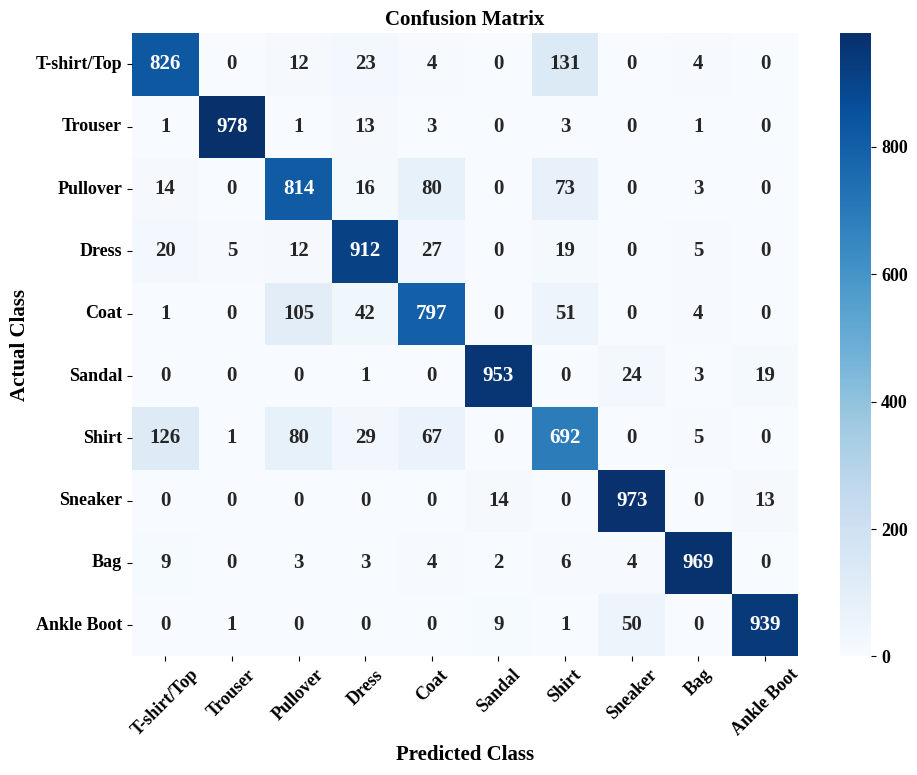

In [19]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10,8))
sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=class_names,yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("Confusion_Matrix.eps",format="eps",bbox_inches="tight")
plt.show()

In [20]:
!pip uninstall -y scikit-learn
!pip install scikit-learn==1.7.1

Found existing installation: scikit-learn 1.7.1
Uninstalling scikit-learn-1.7.1:
  Successfully uninstalled scikit-learn-1.7.1
  Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.1-cp311-cp311-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (9.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sklearn-compat 0.1.3 requires scikit-learn<1.7,>=1.2, but you have scikit-learn 1.7.1 which is incompatible.


In [21]:
def create_model(hidden_layers=2,
                 neurons=128,
                 learning_rate=0.001,
                 optimizer='adam',
                 activation='relu',
                 dropout_rate=0.0):
    model = Sequential()
    model.add(Input(shape=(784,)))
    for i in range(hidden_layers):
        model.add(Dense(neurons,activation=activation))
        if dropout_rate>0:
            model.add(Dropout(dropout_rate))
    model.add(Dense(10,activation='softmax'))
    if optimizer=='adam':
        opt=Adam(learning_rate)
    elif optimizer=='sgd':
        opt=SGD(learning_rate)
    else:
        opt=RMSprop(learning_rate)
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [22]:
model_search = KerasClassifier(
    model=create_model,
    verbose=0
)
print(model_search)

KerasClassifier(
	model=<function create_model at 0x7a3a80b6f600>
	build_fn=None
	warm_start=False
	random_state=None
	optimizer=rmsprop
	loss=None
	metrics=None
	batch_size=None
	validation_batch_size=None
	verbose=0
	callbacks=None
	validation_split=0.0
	shuffle=True
	run_eagerly=False
	epochs=1
	class_weight=None
)


In [23]:
param_grid = {
    'model__hidden_layers': [1, 2, 3],
    'model__neurons': [32, 64, 128, 256],
    'model__learning_rate': [0.1, 0.01, 0.001],
    'model__optimizer': ['adam', 'sgd', 'rmsprop'],
    'model__activation': ['relu', 'tanh', 'sigmoid'],
    'model__dropout_rate': [0.0, 0.2, 0.5],
    'batch_size': [16, 32, 64, 128],
    'epochs': [10, 20, 30]
}

In [24]:
random_search = RandomizedSearchCV(
    estimator=model_search,
    param_distributions=param_grid,
    n_iter=10,
    cv=5,
    scoring='accuracy',
    random_state=42,
    n_jobs=1
)
random_search.fit(X_train, y_train_cat)

,estimator,KerasClassifi..._weight=None )
,param_distributions,"{'batch_size': [16, 32, ...], 'epochs': [10, 20, ...], 'model__activation': ['relu', 'tanh', ...], 'model__dropout_rate': [0.0, 0.2, ...], ...}"
,n_iter,10
,scoring,'accuracy'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [25]:
print("Best Hyperparameters\n")
for key, value in random_search.best_params_.items():
    print(f"{key}: {value}")
print("\nBest Cross Validation Accuracy:",random_search.best_score_)

Best Hyperparameters

model__optimizer: sgd
model__neurons: 128
model__learning_rate: 0.1
model__hidden_layers: 1
model__dropout_rate: 0.0
model__activation: tanh
epochs: 30
batch_size: 32

Best Cross Validation Accuracy: 0.8882999999999999


In [26]:
best_params = random_search.best_params_

In [27]:
optimized_model = create_model(
    hidden_layers=best_params['model__hidden_layers'],
    neurons=best_params['model__neurons'],
    learning_rate=best_params['model__learning_rate'],
    optimizer=best_params['model__optimizer'],
    activation=best_params['model__activation'],
    dropout_rate=best_params['model__dropout_rate']
)

In [28]:
start_time = time.time()
history_opt = optimized_model.fit(
    X_train,
    y_train_cat,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)
end_time = time.time()
optimized_training_time = end_time - start_time
print(f"Optimized Training Time:{optimized_training_time} seconds")

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7560 - loss: 0.6861 - val_accuracy: 0.8203 - val_loss: 0.4929
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8449 - loss: 0.4275 - val_accuracy: 0.8536 - val_loss: 0.3993
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.8620 - loss: 0.3824 - val_accuracy: 0.8604 - val_loss: 0.3886
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8690 - loss: 0.3620 - val_accuracy: 0.8647 - val_loss: 0.3702
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8745 - loss: 0.3405 - val_accuracy: 0.8681 - val_loss: 0.3709
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8805 - loss: 0.3276 - val_accuracy: 0.8773 - val_loss: 0.3380
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8853 - loss: 0.3120 - val_accuracy: 0.8755 - val_loss: 0.3438
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8859 - loss: 0.3058

In [29]:
y_pred_prob = optimized_model.predict(X_test)
y_pred_opt = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [30]:
accuracy_opt = accuracy_score(y_true, y_pred_opt)
precision_opt = precision_score(y_true,y_pred_opt,average='weighted')
recall_opt = recall_score(y_true,y_pred_opt,average='weighted')
f1_opt = f1_score(y_true,y_pred_opt,average='weighted')
print("Accuracy:", accuracy_opt)
print("Precision:", precision_opt)
print("Recall:", recall_opt)
print("F1 Score:", f1_opt)

Accuracy: 0.8755
Precision: 0.8780210026081376
Recall: 0.8755
F1 Score: 0.8762435966497369


In [31]:
print(classification_report(y_true, y_pred_opt))

              precision    recall  f1-score   support

           0       0.81      0.81      0.81      1000
           1       1.00      0.96      0.98      1000
           2       0.81      0.75      0.78      1000
           3       0.89      0.88      0.89      1000
           4       0.82      0.79      0.80      1000
           5       0.95      0.96      0.96      1000
           6       0.65      0.73      0.69      1000
           7       0.96      0.93      0.94      1000
           8       0.94      0.97      0.96      1000
           9       0.94      0.96      0.95      1000

    accuracy                           0.88     10000
   macro avg       0.88      0.88      0.88     10000
weighted avg       0.88      0.88      0.88     10000



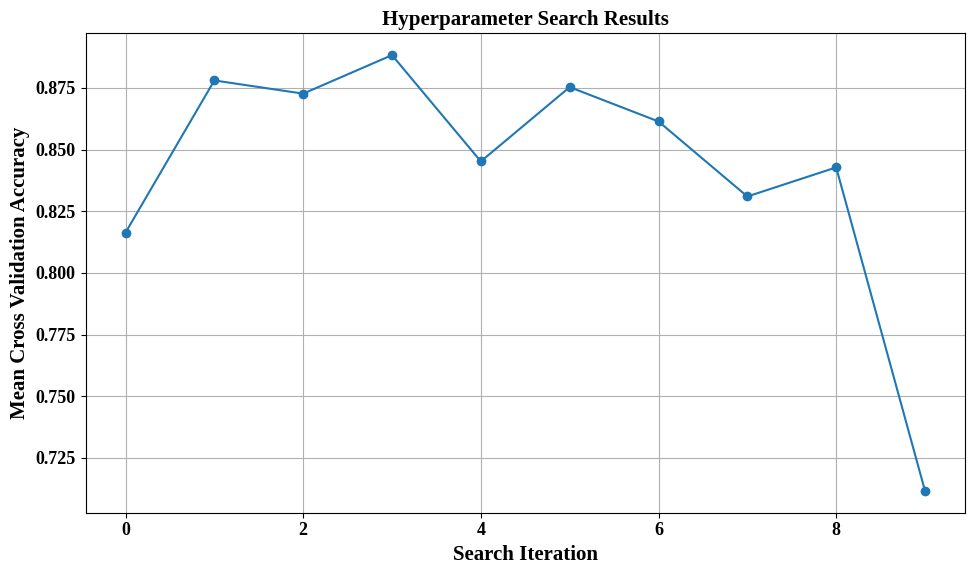

In [32]:
results = random_search.cv_results_
plt.figure(figsize=(10,6))
plt.plot(results["mean_test_score"],marker='o')
plt.title("Hyperparameter Search Results")
plt.xlabel("Search Iteration")
plt.ylabel("Mean Cross Validation Accuracy")
plt.grid(True)
plt.tight_layout()
plt.savefig("Hyperparameter_Search_Results.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

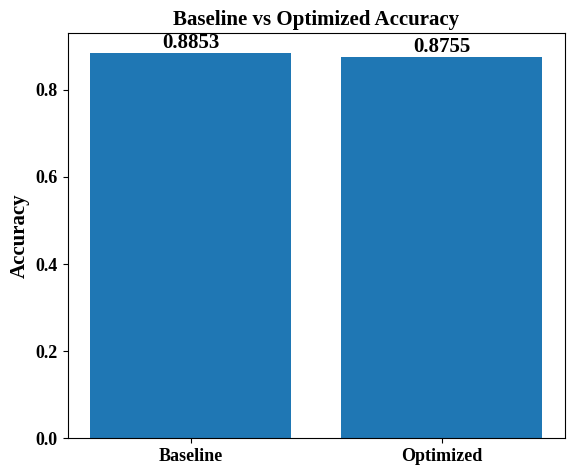

In [33]:
plt.figure(figsize=(6,5))
models = ["Baseline", "Optimized"]
accuracies = [accuracy, accuracy_opt]
plt.bar(models, accuracies)
plt.title("Baseline vs Optimized Accuracy")
plt.ylabel("Accuracy")
for i, value in enumerate(accuracies):
    plt.text(i, value, f"{value:.4f}",ha='center',va='bottom')
plt.tight_layout()
plt.savefig("Accuracy_Comparison.eps",format="eps",dpi=600,bbox_inches="tight")
plt.show()

In [34]:
comparison = pd.DataFrame({
    "Metric":["Accuracy","Precision","Recall","F1-score","Training Time (s)"],
    "Baseline": [accuracy,precision,recall,f1,baseline_training_time],
    "Optimized": [accuracy_opt,precision_opt,recall_opt,f1_opt,optimized_training_time]
})
comparison

,Metric,Baseline,Optimized
0,Accuracy,0.885300,0.875500
1,Precision,0.885449,0.878021
2,Recall,0.885300,0.875500
3,F1-score,0.885212,0.876244
4,Training Time (s),114.760359,172.467539


Additional Exercise:

XOR Gate

In [35]:
X = np.array([
    [0,0],
    [0,1],
    [1,0],
    [1,1]
])
y = np.array([0,1,1,0])

In [36]:
np.random.seed(42)
learning_rate = 0.1
epochs = 1000
weights = np.random.uniform(-1, 1, 2)
bias = np.random.uniform(-1, 1)
print("Initial Weights :", weights)
print("Initial Bias :", bias)
update_count = 0
saved_models = []
converged = False

Initial Weights : [-0.25091976  0.90142861]
Initial Bias : 0.4639878836228102


In [37]:
def step_function(x):
    return 1 if x >= 0 else 0

In [38]:
for epoch in range(epochs):
    errors = 0
    for i in range(len(X)):
        net = np.dot(X[i], weights) + bias
        prediction = step_function(net)
        error = y[i] - prediction
        if error != 0:
            errors += 1
            update_count += 1
            weights = weights + learning_rate * error * X[i]
            bias = bias + learning_rate * error
            print(f"Weight Update : {update_count}")
            print(f"Epoch         : {epoch+1}")
            print(f"Training Sample : {X[i]}")
            print(f"Target Output   : {y[i]}")
            print(f"Predicted Output: {prediction}")
            print(f"Error           : {error}")
            print("Updated Weights :", weights)
            print("Updated Bias    :", bias)
            saved_models.append({
                "update": update_count,
                "weights": weights.copy(),
                "bias": bias
            })
    if errors == 0:
        converged = True
        print("\nPerceptron converged.")
        break

Streaming output truncated to the last 5000 lines.
Weight Update : 3358
Epoch         : 844
Training Sample : [1 1]
Target Output   : 0
Predicted Output: 1
Error           : -1
Updated Weights : [-0.25091976  0.00142861]
Updated Bias    : 0.06398788362281022
Weight Update : 3359
Epoch         : 845
Training Sample : [0 0]
Target Output   : 0
Predicted Output: 1
Error           : -1
Updated Weights : [-0.25091976  0.00142861]
Updated Bias    : -0.03601211637718979
Weight Update : 3360
Epoch         : 845
Training Sample : [0 1]
Target Output   : 1
Predicted Output: 0
Error           : 1
Updated Weights : [-0.25091976  0.10142861]
Updated Bias    : 0.06398788362281022
Weight Update : 3361
Epoch         : 845
Training Sample : [1 0]
Target Output   : 1
Predicted Output: 0
Error           : 1
Updated Weights : [-0.15091976  0.10142861]
Updated Bias    : 0.16398788362281022
Weight Update : 3362
Epoch         : 845
Training Sample : [1 1]
Target Output   : 0
Predicted Output: 1
Error        

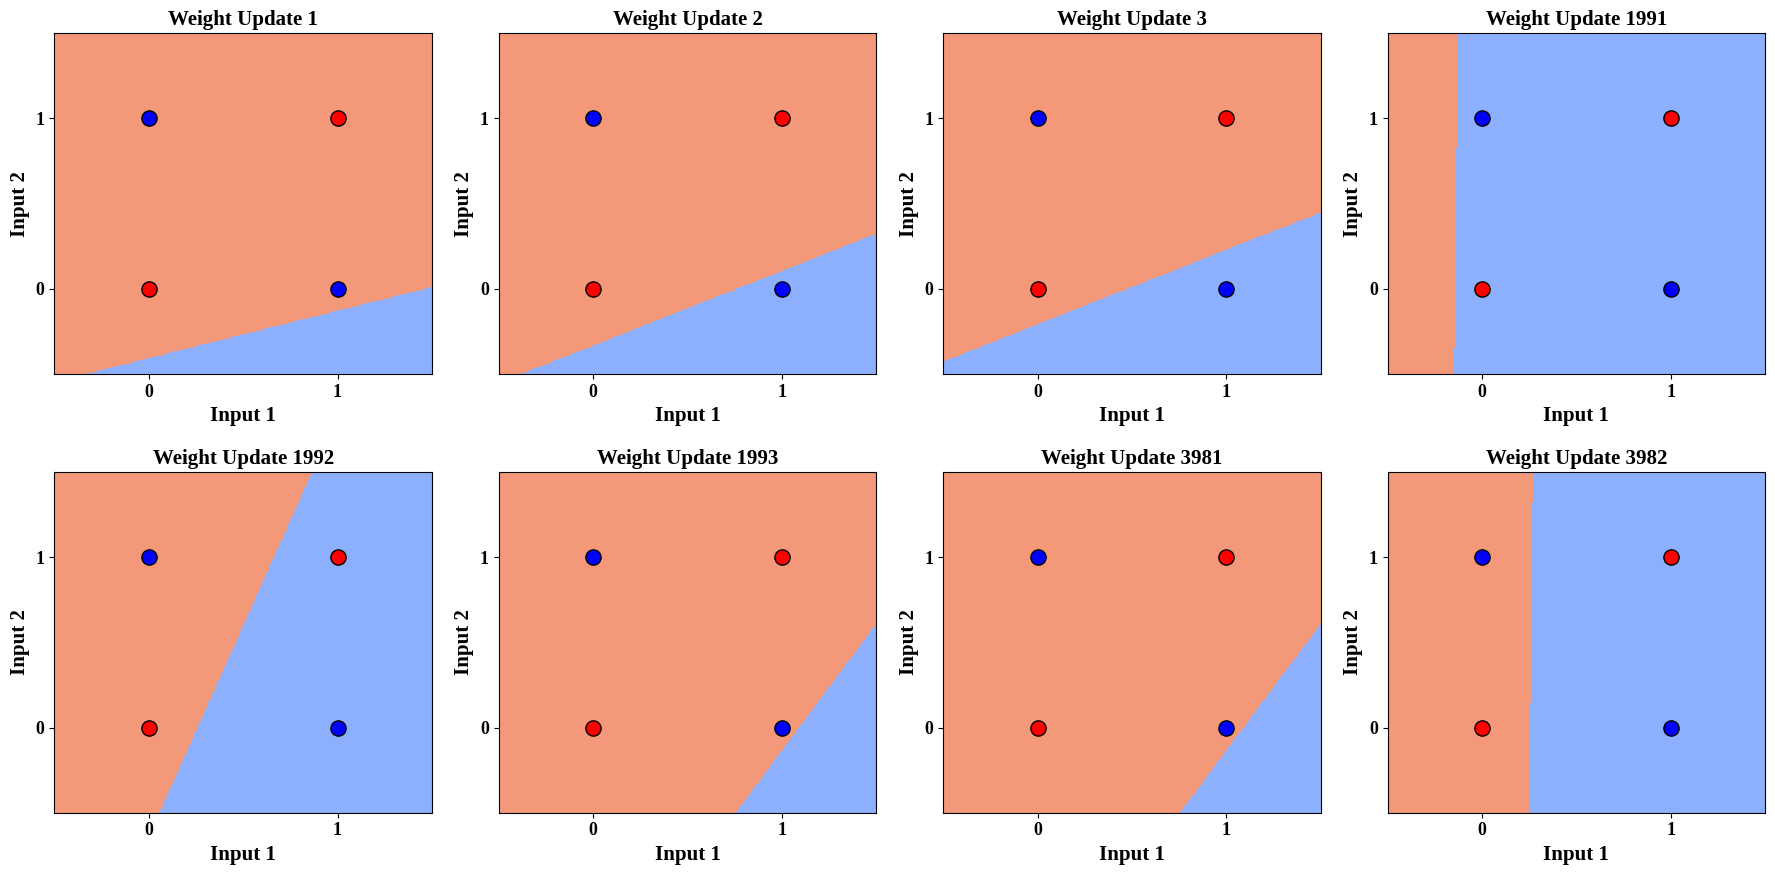

In [39]:
total_updates = len(saved_models)
if total_updates >= 8:
    middle = total_updates // 2
    selected_models = [
        saved_models[0],
        saved_models[1],
        saved_models[2],
        saved_models[middle - 1],
        saved_models[middle],
        saved_models[middle + 1],
        saved_models[-2],
        saved_models[-1]
    ]
else:
    selected_models = saved_models
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()
for i, model in enumerate(selected_models):
    ax = axes[i]
    xx, yy = np.meshgrid(
        np.linspace(-0.5, 1.5, 300),
        np.linspace(-0.5, 1.5, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    predictions = []
    for point in grid:
        net = np.dot(point, model["weights"]) + model["bias"]
        pred = step_function(net)
        predictions.append(pred)
    Z = np.array(predictions).reshape(xx.shape)
    ax.contourf(xx,yy,Z,levels=[-0.5, 0.5, 1.5],cmap="coolwarm")
    ax.scatter(X[y == 0][:, 0],X[y == 0][:, 1],color="red",edgecolors="black",s=120,label="Class 0")
    ax.scatter(X[y == 1][:, 0],X[y == 1][:, 1],color="blue",edgecolors="black",s=120,label="Class 1")
    ax.set_xlim(-0.5, 1.5)
    ax.set_ylim(-0.5, 1.5)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xlabel("Input 1")
    ax.set_ylabel("Input 2")
    ax.set_title(f"Weight Update {model['update']}")
for j in range(len(selected_models), len(axes)):
    axes[j].axis("off")
plt.tight_layout()
plt.savefig("XOR_Decision_Boundaries.eps",format="eps",dpi=300,bbox_inches="tight")
plt.show()